# Online Learning for Sparse Portfolio Optimization

This notebook implements the "Online Proximal Gradient Descent" algorithm to maximize the Differential Sortino Ratio (DSOR) under Indian Market Frictions.

**Key Features:**
* [cite_start]**Asymmetric Risk:** Targets downside risk minimization sequentially[cite: 84].
* [cite_start]**Cardinality Constraints:** Enforces a $k$-set allocation constraint using Iterative Hard Thresholding to prevent portfolio fragmentation[cite: 122, 128].
* [cite_start]**Market Frictions:** Models deterministic linear penalties (like the Budget 2026 STT mandates) and non-linear market impact costs (square-root law)[cite: 136, 137, 145].

In [5]:
import asyncio
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from dataclasses import dataclass, field
from typing import Dict, List
from IPython.display import display, clear_output

# Import core simulation components from your repository
from market_feed.matrix_store_1m import MatrixStoreMinuteFeed
from execution.paper import PaperExecutionEngine
from runner.engine import _rebalance
from common.events import MarketSnapshot, OrderRequest, PositionSnapshot

# --- 1. Helper Functions ---
def project_simplex(v: np.ndarray) -> np.ndarray:
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(v) + 1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(v - theta, 0)

def iterative_hard_thresholding(w: np.ndarray, k: int) -> np.ndarray:
    if k >= len(w) or k <= 0:
        return project_simplex(w)
    idx = np.argpartition(w, -k)[-k:]
    w_sparse = np.zeros_like(w)
    w_sparse[idx] = w[idx]
    w_sparse[idx] = project_simplex(w_sparse[idx])
    return w_sparse

# --- 2. The Statistically Enhanced Strategy ---
@dataclass
class SparseDSORStrategy:
    learning_rate: float = 0.1
    adaptation_rate: float = 0.05
    target_return: float = 0.0
    cardinality: int = 15
    capital: float = 1_000_000.0
    
    # Friction models (Budget 2026 STT & Square-root impact)
    stt_buy: float = 0.001
    stt_sell: float = 0.001
    impact_gamma: float = 0.1
    
    # Horizons
    rebalance_minutes: int = 375 # 1 trading day
    lookback_days: int = 20      # Statistical momentum lookback
    
    _ticks: int = 0
    _history: Dict[str, List[float]] = field(default_factory=dict)
    _symbols: List[str] = field(default_factory=list)
    _last_target_weights: Dict[str, float] = field(default_factory=dict)
    
    _A: float = 0.0
    _B: float = 1e-6
    _w_prev: np.ndarray = field(init=False)
    _history_len: int = field(init=False)
    
    def __post_init__(self):
        self._w_prev = np.array([])
        # Need enough memory to capture the full lookback window
        self._history_len = (self.rebalance_minutes * self.lookback_days) + 1
        
    def _calculate_frictions(self, w_target: np.ndarray, w_drifted: np.ndarray, volatilities: np.ndarray) -> float:
        diff = w_target - w_drifted
        buy_costs = self.stt_buy * np.sum(np.maximum(diff, 0))
        sell_costs = self.stt_sell * np.sum(np.maximum(-diff, 0))
        phi_linear = buy_costs + sell_costs
        V_i = self.capital * 100 
        impact_penalty = self.impact_gamma * volatilities * np.sqrt((np.abs(diff) * self.capital) / V_i) * np.abs(diff)
        phi_impact = np.sum(impact_penalty)
        return phi_linear + phi_impact

    def on_snapshot(self, snap: MarketSnapshot, portfolio: PositionSnapshot) -> List[OrderRequest]:
        self._ticks += 1
        
        # 1. Track price history up to the full statistical horizon
        for sym, px in snap.prices.items():
            if math.isfinite(px) and px > 0:
                self._history.setdefault(sym, []).append(float(px))
                if len(self._history[sym]) > self._history_len:
                    self._history[sym].pop(0)
                if sym not in self._symbols:
                    self._symbols.append(sym)
                    
        # 2. Early Exit: Only compute new weights at the daily close
        if self._ticks % self.rebalance_minutes != 0:
            return []
            
        if len(self._symbols) < self.cardinality:
            return []
            
        N = len(self._symbols)
        if len(self._w_prev) != N:
            new_w = np.zeros(N)
            new_w[:len(self._w_prev)] = self._w_prev
            self._w_prev = new_w if np.sum(new_w) > 0 else np.ones(N)/N

        raw_returns = np.zeros(N)
        volatilities = np.ones(N) * 0.01
        
        # 3. Compute Momentum over the lookback window
        for i, sym in enumerate(self._symbols):
            series = self._history.get(sym, [])
            # Only evaluate assets that have at least 10 days of history
            if len(series) >= self.rebalance_minutes * 10:
                raw_returns[i] = (series[-1] / series[0]) - 1.0
                volatilities[i] = np.std(series) / np.mean(series)

        # 4. Statistical Filter: Cross-Sectional Z-Score
        active_returns = raw_returns[raw_returns != 0]
        if len(active_returns) > 2:
            cross_mean = np.mean(active_returns)
            cross_std = np.std(active_returns)
            # Normalize signals and clip extreme outliers to prevent gradient explosion
            stat_signals = np.clip((raw_returns - cross_mean) / (cross_std + 1e-8), -3.0, 3.0)
        else:
            stat_signals = raw_returns

        # 5. Online Gradient Descent Math (Using Z-Scores)
        portfolio_return = np.dot(self._w_prev, raw_returns)
        w_drifted = (self._w_prev * (1 + raw_returns)) / (1 + portfolio_return)

        phi_total = self._calculate_frictions(self._w_prev, w_drifted, volatilities)
        R_t = portfolio_return - phi_total
        
        R_down = min(R_t - self.target_return, 0.0)
        self._A = self._A + self.adaptation_rate * (R_t - self._A)
        self._B = self._B + self.adaptation_rate * ((R_down ** 2) - self._B)
        
        B_safe = max(self._B, 1e-8)
        downside_indicator = 1.0 if R_t < self.target_return else 0.0
        penalty_term = (self._A - self.target_return) * (R_t - self.target_return) * downside_indicator
        
        # Gradient scaling factor based on DSOR
        d_D_d_R = (B_safe - penalty_term) / (B_safe ** 1.5)
        
        # Multiply scaling factor by our smoothed statistical signals, NOT raw noise
        grad_w = d_D_d_R * stat_signals 

        # 6. Proximal Update & Sparse Projection
        w_hat = self._w_prev + self.learning_rate * grad_w
        w_t = iterative_hard_thresholding(w_hat, self.cardinality)
        
        self._w_prev = w_t
        self._last_target_weights = {self._symbols[i]: float(w_t[i]) for i in range(N) if w_t[i] > 0}
        
        return []

# --- 3. The Optimized 10-Year Run Loop ---
async def run_notebook_backtest():
    feed = MatrixStoreMinuteFeed(
        store_dir="E:/data_1m/processed_data/nifty500/1m_cube_store", 
        symbols=None,  
        start=datetime(2015, 2, 2, 9, 15),                             
        end=datetime(2024, 1, 1, 15, 30),                              
        speed="fast"
    )
    
    initial_capital = 1_000_000.0
    exe = PaperExecutionEngine(
        initial_cash=initial_capital, 
        fees_bps=1.0, 
        slippage_bps=0.5
    )
    
    strat = SparseDSORStrategy(
        cardinality=15,               
        capital=initial_capital,
        learning_rate=0.05,        # Slightly lowered to prevent overreacting to Z-scores
        adaptation_rate=0.05,
        lookback_days=20
    )
    
    nav_history = []
    timestamps = []
    tick_count = 0
    
    port = exe.snapshot(datetime(2015, 2, 2, 9, 15))
    print("Starting 10-Year Simulation Loop... (This will take some time)")
    
    async for snap in feed.stream():
        tick_count += 1
        
        exe.update_market(snap)
        strat.on_snapshot(snap, port)
        
        # Only route orders when the strategy updates its weights
        if hasattr(strat, "_last_target_weights") and strat._last_target_weights and (tick_count % strat.rebalance_minutes == 0):
            orders = _rebalance(snap.ts, strat._last_target_weights, snap, port)
            if orders:
                execution_events = exe.place_orders(snap.ts, orders)
                for evt in execution_events:
                    if isinstance(evt, dict) and evt.get("kind") == "position_snapshot":
                        port = PositionSnapshot(**evt)
        
        port = exe.snapshot(snap.ts)
        nav_history.append(float(port.nav))
        timestamps.append(snap.ts)
        
        # Throttled UI Update
        if tick_count % 100 == 0:
            clear_output(wait=True)
            print("="*50)
            print(f"⏱️ LIVE SIMULATION TIME: {snap.ts.strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"📈 TOTAL NAV:          ₹{port.nav:,.2f}")
            print(f"📊 RETURN:             {((port.nav / initial_capital) - 1) * 100:.2f}%")
            print(f"⚙️ PROCESSED TICKS:    {tick_count:,}")
            print("-" * 50)
            print("Trading is active... UI throttled for speed.")
            print("="*50)

    clear_output(wait=True)
    print(f"✅ 10-Year Simulation Complete! Final NAV: ₹{nav_history[-1]:,.2f}")
    print(f"Total market ticks processed: {tick_count:,}")
    
    df = pd.DataFrame({"ts": timestamps, "NAV": nav_history}).set_index("ts")
    
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df["NAV"], label="DSOR Stat-Arb Strategy", color="#2ca02c", linewidth=1.5)
    plt.axhline(y=initial_capital, color='r', linestyle='--', alpha=0.5, label="Initial Capital")
    plt.title("10-Year Portfolio NAV over Time")
    plt.xlabel("Time")
    plt.ylabel("Net Asset Value (₹)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return df, strat

# Run the async loop inside Jupyter
result_df, trained_strat = await run_notebook_backtest()

⏱️ LIVE SIMULATION TIME: 2015-05-14 09:46:00
📈 TOTAL NAV:          ₹224,727.26
📊 RETURN:             -77.53%
⚙️ PROCESSED TICKS:    25,600
--------------------------------------------------
Trading is active... UI throttled for speed.


CancelledError: 

# HMM-Enhanced Strategy Cell

In [6]:
import asyncio
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from dataclasses import dataclass, field
from typing import Dict, List
from IPython.display import display, clear_output

try:
    from hmmlearn.hmm import GaussianHMM
except ImportError:
    raise ImportError("Please install hmmlearn using 'pip install hmmlearn' to run this model.")

# Import core simulation components from your repository
from market_feed.matrix_store_1m import MatrixStoreMinuteFeed
from execution.paper import PaperExecutionEngine
from runner.engine import _rebalance
from common.events import MarketSnapshot, OrderRequest, PositionSnapshot

# --- 1. Helper Functions ---
def project_simplex(v: np.ndarray) -> np.ndarray:
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(v) + 1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(v - theta, 0)

def iterative_hard_thresholding(w: np.ndarray, k: int) -> np.ndarray:
    if k >= len(w) or k <= 0:
        return project_simplex(w)
    idx = np.argpartition(w, -k)[-k:]
    w_sparse = np.zeros_like(w)
    w_sparse[idx] = w[idx]
    w_sparse[idx] = project_simplex(w_sparse[idx])
    return w_sparse

# --- 2. The HMM + Stat-Arb Enhanced Strategy ---
@dataclass
class SparseDSORStrategy:
    learning_rate: float = 0.1
    adaptation_rate: float = 0.05
    target_return: float = 0.0
    cardinality: int = 15
    capital: float = 1_000_000.0
    
    stt_buy: float = 0.001
    stt_sell: float = 0.001
    impact_gamma: float = 0.1
    
    rebalance_minutes: int = 375 # 1 trading day
    lookback_days: int = 20      # Momentum lookback
    hmm_lookback_days: int = 100 # How much market history to fit the HMM
    
    _ticks: int = 0
    _history: Dict[str, List[float]] = field(default_factory=dict)
    _daily_market_returns: List[float] = field(default_factory=list) # Tracks the universe mean
    _symbols: List[str] = field(default_factory=list)
    _last_target_weights: Dict[str, float] = field(default_factory=dict)
    
    _A: float = 0.0
    _B: float = 1e-6
    _w_prev: np.ndarray = field(init=False)
    _history_len: int = field(init=False)
    
    def __post_init__(self):
        self._w_prev = np.array([])
        self._history_len = (self.rebalance_minutes * self.lookback_days) + 1
        
    def _calculate_frictions(self, w_target: np.ndarray, w_drifted: np.ndarray, volatilities: np.ndarray) -> float:
        diff = w_target - w_drifted
        buy_costs = self.stt_buy * np.sum(np.maximum(diff, 0))
        sell_costs = self.stt_sell * np.sum(np.maximum(-diff, 0))
        phi_linear = buy_costs + sell_costs
        V_i = self.capital * 100 
        impact_penalty = self.impact_gamma * volatilities * np.sqrt((np.abs(diff) * self.capital) / V_i) * np.abs(diff)
        return phi_linear + np.sum(impact_penalty)

    def on_snapshot(self, snap: MarketSnapshot, portfolio: PositionSnapshot) -> List[OrderRequest]:
        self._ticks += 1
        
        # 1. Track Price History
        for sym, px in snap.prices.items():
            if math.isfinite(px) and px > 0:
                self._history.setdefault(sym, []).append(float(px))
                if len(self._history[sym]) > self._history_len:
                    self._history[sym].pop(0)
                if sym not in self._symbols:
                    self._symbols.append(sym)
                    
        # 2. Wait for the daily close to perform heavy computations
        if self._ticks % self.rebalance_minutes != 0:
            return []
            
        if len(self._symbols) < self.cardinality:
            return []
            
        N = len(self._symbols)
        if len(self._w_prev) != N:
            new_w = np.zeros(N)
            new_w[:len(self._w_prev)] = self._w_prev
            self._w_prev = new_w if np.sum(new_w) > 0 else np.ones(N)/N

        raw_returns = np.zeros(N)
        volatilities = np.ones(N) * 0.01
        
        for i, sym in enumerate(self._symbols):
            series = self._history.get(sym, [])
            if len(series) >= self.rebalance_minutes * 10:
                raw_returns[i] = (series[-1] / series[0]) - 1.0
                volatilities[i] = np.std(series) / np.mean(series)

        active_returns = raw_returns[raw_returns != 0]
        
        # --- HIDDEN MARKOV MODEL: Latent Regime Inference ---
        regime_cash_penalty = 1.0
        active_lr = self.learning_rate
        
        if len(active_returns) > 0:
            cross_mean = np.mean(active_returns)
            self._daily_market_returns.append(cross_mean)
            
            # Keep HMM memory window bounded
            if len(self._daily_market_returns) > self.hmm_lookback_days:
                self._daily_market_returns.pop(0)
                
            # Fit HMM only when we have sufficient sequence data (e.g., 50 days)
            if len(self._daily_market_returns) >= 50:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    try:
                        X = np.array(self._daily_market_returns).reshape(-1, 1)
                        # 2-State Model: Calm vs. Volatile
                        model = GaussianHMM(n_components=2, covariance_type="diag", n_iter=50, random_state=42)
                        model.fit(X)
                        pred_states = model.predict(X)
                        current_state = pred_states[-1]
                        
                        # Identify the high-variance (Bear) state
                        vol_state_0 = model.covars_[0][0][0]
                        vol_state_1 = model.covars_[1][0][0]
                        bear_state = 1 if vol_state_1 > vol_state_0 else 0
                        
                        if current_state == bear_state:
                            # Volatile Regime Detected: Defensive posture
                            active_lr = self.learning_rate * 0.2  # Shrink learning rate by 80%
                            regime_cash_penalty = 0.5             # Move 50% to cash
                    except Exception:
                        pass # Fallback to standard logic if HMM fails to converge

        # --- STATISTICAL FILTER: Z-Score ---
        if len(active_returns) > 2:
            cross_std = np.std(active_returns)
            stat_signals = np.clip((raw_returns - cross_mean) / (cross_std + 1e-8), -3.0, 3.0)
        else:
            stat_signals = raw_returns

        # --- DIFFERENTIAL SORTINO OPTIMIZATION ---
        portfolio_return = np.dot(self._w_prev, raw_returns)
        w_drifted = (self._w_prev * (1 + raw_returns)) / (1 + portfolio_return)

        phi_total = self._calculate_frictions(self._w_prev, w_drifted, volatilities)
        R_t = portfolio_return - phi_total
        
        R_down = min(R_t - self.target_return, 0.0)
        self._A = self._A + self.adaptation_rate * (R_t - self._A)
        self._B = self._B + self.adaptation_rate * ((R_down ** 2) - self._B)
        
        B_safe = max(self._B, 1e-8)
        downside_indicator = 1.0 if R_t < self.target_return else 0.0
        penalty_term = (self._A - self.target_return) * (R_t - self.target_return) * downside_indicator
        
        d_D_d_R = (B_safe - penalty_term) / (B_safe ** 1.5)
        
        # Scale gradient by the active (potentially shrunken) learning rate
        grad_w = d_D_d_R * stat_signals 
        w_hat = self._w_prev + active_lr * grad_w
        
        # Project onto the k-sparse simplex
        w_t = iterative_hard_thresholding(w_hat, self.cardinality)
        
        # Apply the HMM Cash Penalty (Deflating the simplex weights moves capital to Cash)
        w_t = w_t * regime_cash_penalty
        
        self._w_prev = w_t
        self._last_target_weights = {self._symbols[i]: float(w_t[i]) for i in range(N) if w_t[i] > 0}
        
        return []

# --- 3. The Optimized 10-Year Run Loop ---
async def run_notebook_backtest():
    feed = MatrixStoreMinuteFeed(
        store_dir="E:/data_1m/processed_data/nifty500/1m_cube_store_repaired", #
        symbols=None,  
        start=datetime(2015, 2, 2, 9, 15),                             
        end=datetime(2024, 1, 1, 15, 30),                              
        speed="fast"
    )
    
    initial_capital = 10_000_000
    exe = PaperExecutionEngine(
        initial_cash=initial_capital, 
        fees_bps=1.0, 
        slippage_bps=0.5
    )
    
    strat = SparseDSORStrategy(
        cardinality=30,               
        capital=initial_capital,
        learning_rate=0.05,        
        adaptation_rate=0.05
    )
    
    nav_history = []
    timestamps = []
    tick_count = 0
    
    port = exe.snapshot(datetime(2015, 2, 2, 9, 15))
    print("Starting 10-Year Simulation Loop... (This will take some time)")
    
    async for snap in feed.stream():
        tick_count += 1
        
        exe.update_market(snap)
        strat.on_snapshot(snap, port)
        
        if hasattr(strat, "_last_target_weights") and strat._last_target_weights and (tick_count % strat.rebalance_minutes == 0):
            orders = _rebalance(snap.ts, strat._last_target_weights, snap, port)
            if orders:
                execution_events = exe.place_orders(snap.ts, orders)
                for evt in execution_events:
                    if isinstance(evt, dict) and evt.get("kind") == "position_snapshot":
                        port = PositionSnapshot(**evt)
        
        port = exe.snapshot(snap.ts)
        nav_history.append(float(port.nav))
        timestamps.append(snap.ts)
        
        # Throttled UI Update
        if tick_count % 100 == 0:
            clear_output(wait=True)
            print("="*50)
            print(f"⏱️ LIVE SIMULATION TIME: {snap.ts.strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"📈 TOTAL NAV:          ₹{port.nav:,.2f}")
            print(f"📊 RETURN:             {((port.nav / initial_capital) - 1) * 100:.2f}%")
            print(f"⚙️ PROCESSED TICKS:    {tick_count:,}")
            print("-" * 50)
            print("Trading is active... UI throttled for speed.")
            print("="*50)

    clear_output(wait=True)
    print(f"✅ 10-Year Simulation Complete! Final NAV: ₹{nav_history[-1]:,.2f}")
    print(f"Total market ticks processed: {tick_count:,}")
    
    df = pd.DataFrame({"ts": timestamps, "NAV": nav_history}).set_index("ts")
    
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df["NAV"], label="DSOR + HMM Regime Strategy", color="#2ca02c", linewidth=1.5)
    plt.axhline(y=initial_capital, color='r', linestyle='--', alpha=0.5, label="Initial Capital")
    plt.title("10-Year Portfolio NAV over Time")
    plt.xlabel("Time")
    plt.ylabel("Net Asset Value (₹)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return df, strat

# Run the async loop inside Jupyter
result_df, trained_strat = await run_notebook_backtest()

⏱️ LIVE SIMULATION TIME: 2015-04-06 14:22:00
📈 TOTAL NAV:          ₹9,930,807.87
📊 RETURN:             -0.69%
⚙️ PROCESSED TICKS:    16,100
--------------------------------------------------
Trading is active... UI throttled for speed.


CancelledError: 

✅ 10-Year Simulation Complete! Final NAV: ₹5,713,307,302.00
Total market ticks processed: 826,448


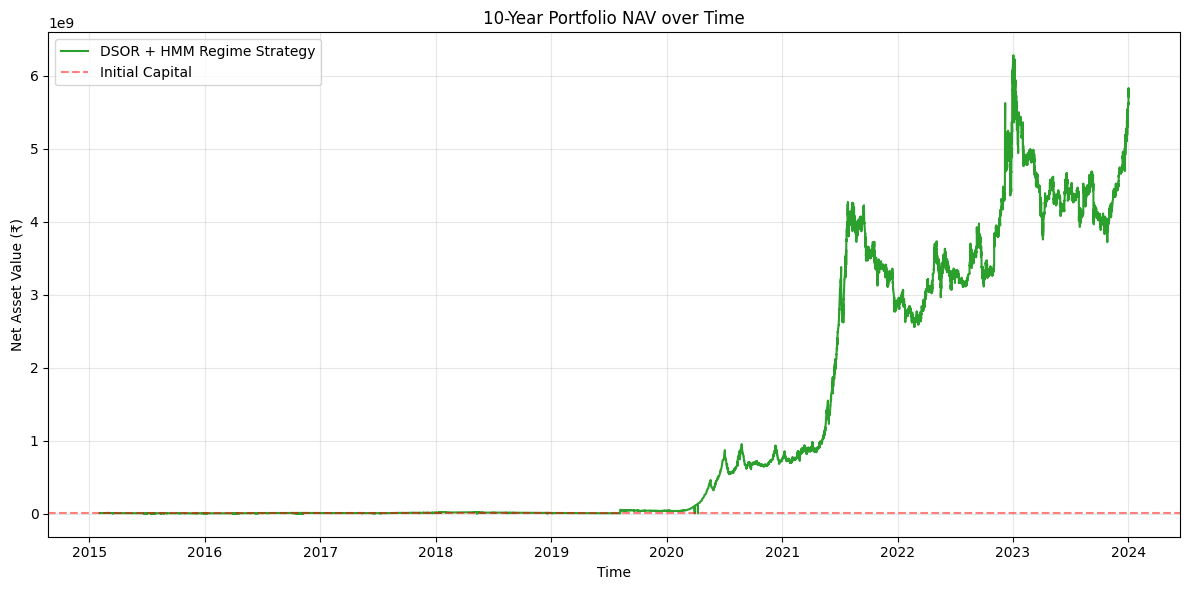

In [3]:
import math
import warnings
import numpy as np
from dataclasses import dataclass, field
from collections import deque
from typing import Dict, List, Deque

from hmmlearn.hmm import GaussianHMM
from common.events import MarketSnapshot, OrderRequest, PositionSnapshot
import asyncio
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from dataclasses import dataclass, field
from typing import Dict, List
from IPython.display import display, clear_output

try:
    from hmmlearn.hmm import GaussianHMM
except ImportError:
    raise ImportError("Please install hmmlearn using 'pip install hmmlearn' to run this model.")

# Import core simulation components from your repository
from market_feed.matrix_store_1m import MatrixStoreMinuteFeed
from execution.paper import PaperExecutionEngine
from runner.engine import _rebalance
from common.events import MarketSnapshot, OrderRequest, PositionSnapshot


def project_simplex(v: np.ndarray) -> np.ndarray:
    v = np.asarray(v, dtype=float)
    if v.size == 0:
        return v

    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    idx = np.where(u * np.arange(1, len(v) + 1) > (cssv - 1))[0]

    if len(idx) == 0:
        out = np.zeros_like(v)
        out[np.argmax(v)] = 1.0
        return out

    rho = idx[-1]
    theta = (cssv[rho] - 1.0) / (rho + 1.0)
    return np.maximum(v - theta, 0.0)


def sparse_simplex_projection(w: np.ndarray, k: int, gross: float = 1.0) -> np.ndarray:
    w = np.asarray(w, dtype=float)
    n = len(w)

    if gross <= 0.0:
        return np.zeros_like(w)

    w = np.clip(w, 0.0, None)

    if k >= n:
        return gross * project_simplex(w)

    idx = np.argpartition(w, -k)[-k:]
    out = np.zeros_like(w)
    out[idx] = project_simplex(w[idx])
    return gross * out


@dataclass
class SparseDSORStrategy:
    learning_rate: float = 0.05
    adaptation_rate: float = 0.02
    target_return: float = 0.0
    cardinality: int = 15
    capital: float = 1_000_000.0

    # objective-side cost estimate (align roughly with your execution engine)
    est_linear_cost_bps: float = 15.0
    impact_gamma: float = 5e-4

    rebalance_minutes: int = 375
    lookback_days: int = 20
    vol_lookback_days: int = 20
    hmm_lookback_days: int = 100
    hmm_min_obs: int = 60

    max_bear_gross: float = 0.50
    min_weight: float = 0.005
    min_turnover: float = 0.02

    _ticks: int = 0
    _symbols: List[str] = field(default_factory=list)
    _close_hist: Dict[str, Deque[float]] = field(default_factory=dict)
    _market_ret_hist: Deque[float] = field(default_factory=deque)
    _market_vol_hist: Deque[float] = field(default_factory=deque)
    _last_target_weights: Dict[str, float] = field(default_factory=dict)

    _A: float = 0.0
    _B: float = 1e-6
    _w_prev: np.ndarray = field(init=False)

    def __post_init__(self):
        self._w_prev = np.array([], dtype=float)
        self._market_ret_hist = deque(maxlen=self.hmm_lookback_days)
        self._market_vol_hist = deque(maxlen=self.hmm_lookback_days)

    def _expand_weights(self, n: int) -> None:
        if len(self._w_prev) == n:
            return
        new_w = np.zeros(n, dtype=float)
        if len(self._w_prev) > 0:
            new_w[:len(self._w_prev)] = self._w_prev
        self._w_prev = new_w

    def _estimate_cost(self, w_target: np.ndarray, w_curr: np.ndarray, vols: np.ndarray) -> float:
        delta = np.abs(w_target - w_curr)
        linear = (self.est_linear_cost_bps / 1e4) * float(delta.sum())
        impact = self.impact_gamma * float(np.sum((delta ** 2) * (1.0 + vols)))
        return linear + impact

    def _infer_regime(self) -> tuple[float, float]:
        if len(self._market_ret_hist) < self.hmm_min_obs:
            return 1.0, self.learning_rate

        X = np.column_stack([
            np.array(self._market_ret_hist, dtype=float),
            np.array(self._market_vol_hist, dtype=float),
        ])

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            try:
                model = GaussianHMM(
                    n_components=2,
                    covariance_type="diag",
                    n_iter=100,
                    random_state=42,
                )
                model.fit(X)
                states = model.predict(X)
                current_state = int(states[-1])

                # bear state = lower mean return + higher mean cross-sectional vol
                state_score = model.means_[:, 0] - model.means_[:, 1]
                bear_state = int(np.argmin(state_score))

                if current_state == bear_state:
                    return self.max_bear_gross, self.learning_rate * 0.5
            except Exception:
                pass

        return 1.0, self.learning_rate

    def on_snapshot(self, snap: MarketSnapshot, portfolio: PositionSnapshot) -> List[OrderRequest]:
        self._ticks += 1

        # symbol discovery
        for sym, px in snap.prices.items():
            if math.isfinite(px) and px > 0:
                if sym not in self._close_hist:
                    self._symbols.append(sym)
                    self._close_hist[sym] = deque(
                        maxlen=max(self.lookback_days, self.vol_lookback_days) + 2
                    )

        # rebalance only once per day
        if self._ticks % self.rebalance_minutes != 0:
            return []

        # record daily close at rebalance point
        for sym in self._symbols:
            px = snap.prices.get(sym, np.nan)
            if math.isfinite(px) and px > 0:
                self._close_hist[sym].append(float(px))

        n = len(self._symbols)
        if n == 0:
            return []

        self._expand_weights(n)

        alpha = np.zeros(n, dtype=float)
        one_day_ret = np.zeros(n, dtype=float)
        vols = np.full(n, 0.02, dtype=float)
        tradable = np.zeros(n, dtype=bool)

        need = max(self.lookback_days, self.vol_lookback_days) + 1

        for i, sym in enumerate(self._symbols):
            hist = np.asarray(self._close_hist.get(sym, []), dtype=float)
            if len(hist) < need:
                continue

            logrets = np.diff(np.log(hist))
            if not np.all(np.isfinite(logrets)):
                continue

            tradable[i] = True
            one_day_ret[i] = float(np.exp(logrets[-1]) - 1.0)
            vols[i] = float(np.std(logrets[-self.vol_lookback_days:]) * np.sqrt(252))

            # simple alpha proxy: momentum scaled by vol
            mom = float(hist[-1] / hist[-1 - self.lookback_days] - 1.0)
            alpha[i] = mom / (vols[i] + 1e-8)

        if tradable.sum() < min(self.cardinality, 3):
            return []

        # sanitize old weights onto tradable universe
        gross_prev = float(np.clip(self._w_prev.sum(), 0.0, 1.0))
        w_prev = self._w_prev.copy()
        w_prev[~tradable] = 0.0

        if w_prev.sum() > 0 and gross_prev > 0:
            w_prev *= gross_prev / w_prev.sum()
        else:
            trad_idx = np.where(tradable)[0]
            top = trad_idx[np.argsort(alpha[trad_idx])[-min(self.cardinality, len(trad_idx)):]]
            seed = np.zeros(n, dtype=float)
            seed[top] = 1.0
            w_prev = sparse_simplex_projection(seed, min(self.cardinality, len(trad_idx)), gross=1.0)

        # market regime features
        market_ret = float(np.mean(one_day_ret[tradable]))
        cross_vol = float(np.std(one_day_ret[tradable]))
        self._market_ret_hist.append(market_ret)
        self._market_vol_hist.append(cross_vol)

        gross_cap, active_lr = self._infer_regime()

        # cross-sectional signal normalization
        signal = np.zeros(n, dtype=float)
        mu = float(alpha[tradable].mean())
        sd = float(alpha[tradable].std()) + 1e-8
        signal[tradable] = np.clip((alpha[tradable] - mu) / sd, -3.0, 3.0)

        # realized return of current portfolio over the just-finished day
        port_ret = float(np.dot(w_prev, one_day_ret))

        # drifted risky weights after market move
        denom = max(1.0 + port_ret, 1e-8)
        w_drifted = (w_prev * (1.0 + one_day_ret)) / denom

        # exponential moving estimates for differential Sortino
        downside = min(port_ret - self.target_return, 0.0)
        self._A = (1.0 - self.adaptation_rate) * self._A + self.adaptation_rate * port_ret
        self._B = (1.0 - self.adaptation_rate) * self._B + self.adaptation_rate * (downside ** 2)

        B_safe = max(self._B, 1e-8)

        # approximate d(Sortino)/dR with EMA chain-rule scaling
        ds_dR = self.adaptation_rate / np.sqrt(B_safe)
        if port_ret < self.target_return:
            ds_dR -= (
                self.adaptation_rate
                * (self._A - self.target_return)
                * (port_ret - self.target_return)
                / (B_safe ** 1.5)
            )

        grad = ds_dR * signal

        # propose new sparse target
        w_candidate = sparse_simplex_projection(
            w_drifted + active_lr * grad,
            k=min(self.cardinality, int(tradable.sum())),
            gross=gross_cap,
        )
        w_candidate[~tradable] = 0.0

        # remove tiny positions
        w_candidate[w_candidate < self.min_weight] = 0.0
        s = float(w_candidate.sum())
        if s > 0:
            w_candidate *= gross_cap / s

        # actual cost must be measured against drifted holdings, not old target
        est_cost = self._estimate_cost(w_candidate, w_drifted, vols)
        turnover = float(np.abs(w_candidate - w_drifted).sum())

        if turnover < self.min_turnover:
            w_target = w_drifted
        else:
            # simple cost-aware acceptance rule
            net_signal_gain = float(np.dot(signal, (w_candidate - w_drifted)))
            w_target = w_candidate if net_signal_gain > est_cost else w_drifted

        self._w_prev = w_target
        self._last_target_weights = {
            self._symbols[i]: float(w_target[i])
            for i in range(n)
            if w_target[i] > 0
        }

        return []
    
# --- 3. The Optimized 10-Year Run Loop ---
async def run_notebook_backtest():
    feed = MatrixStoreMinuteFeed(
        store_dir="E:/data_1m/processed_data/nifty500/1m_cube_store",
        symbols=None,  
        start=datetime(2015, 2, 2, 9, 15),                             
        end=datetime(2024, 1, 1, 15, 30),                              
        speed="fast"
    )
    
    initial_capital = 10_000_000
    exe = PaperExecutionEngine(
        initial_cash=initial_capital, 
        fees_bps=1.0, 
        slippage_bps=0.5
    )
    
    strat = SparseDSORStrategy(
        cardinality=30,               
        capital=initial_capital,
        learning_rate=0.05,        
        adaptation_rate=0.05
    )
    
    nav_history = []
    timestamps = []
    tick_count = 0
    
    port = exe.snapshot(datetime(2015, 2, 2, 9, 15))
    print("Starting 10-Year Simulation Loop... (This will take some time)")
    
    async for snap in feed.stream():
        tick_count += 1
        
        exe.update_market(snap)
        strat.on_snapshot(snap, port)
        
        if hasattr(strat, "_last_target_weights") and strat._last_target_weights and (tick_count % strat.rebalance_minutes == 0):
            orders = _rebalance(snap.ts, strat._last_target_weights, snap, port)
            if orders:
                execution_events = exe.place_orders(snap.ts, orders)
                for evt in execution_events:
                    if isinstance(evt, dict) and evt.get("kind") == "position_snapshot":
                        port = PositionSnapshot(**evt)
        
        port = exe.snapshot(snap.ts)
        nav_history.append(float(port.nav))
        timestamps.append(snap.ts)
        
        # Throttled UI Update
        if tick_count % 100 == 0:
            clear_output(wait=True)
            print("="*50)
            print(f"⏱️ LIVE SIMULATION TIME: {snap.ts.strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"📈 TOTAL NAV:          ₹{port.nav:,.2f}")
            print(f"📊 RETURN:             {((port.nav / initial_capital) - 1) * 100:.2f}%")
            print(f"⚙️ PROCESSED TICKS:    {tick_count:,}")
            print("-" * 50)
            print("Trading is active... UI throttled for speed.")
            print("="*50)

    clear_output(wait=True)
    print(f"✅ 10-Year Simulation Complete! Final NAV: ₹{nav_history[-1]:,.2f}")
    print(f"Total market ticks processed: {tick_count:,}")
    
    df = pd.DataFrame({"ts": timestamps, "NAV": nav_history}).set_index("ts")
    
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df["NAV"], label="DSOR + HMM Regime Strategy", color="#2ca02c", linewidth=1.5)
    plt.axhline(y=initial_capital, color='r', linestyle='--', alpha=0.5, label="Initial Capital")
    plt.title("10-Year Portfolio NAV over Time")
    plt.xlabel("Time")
    plt.ylabel("Net Asset Value (₹)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return df, strat

# Run the async loop inside Jupyter
result_df, trained_strat = await run_notebook_backtest()